In [76]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Define the path to your CSV file
file_path = '/content/drive/MyDrive/PA/dataset.csv'

# Read the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}' into a DataFrame with {len(df)} rows and {len(df.columns)} columns.")
    print("First 5 rows of the DataFrame:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded '/content/drive/MyDrive/PA/dataset.csv' into a DataFrame with 3200 rows and 8 columns.
First 5 rows of the DataFrame:
   crop     N     P     K        pH    rainfall  temperature   humidity
0  rice  90.0  42.0  43.0  6.502985  202.935536    20.879744  82.002744
1  rice  85.0  58.0  41.0  7.038096  226.655537    21.770462  80.319644
2  rice  60.0  55.0  44.0  7.840207  263.964248    23.004459  82.320763
3  rice  74.0  35.0  40.0  6.980401  242.864034    26.491096  80.158363
4  rice  78.0  42.0  42.0  7.628473  262.717340    20.130175  81.604873


## 1. IMPORT LIBRARIES

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. LOAD DATA

In [78]:
from google.colab import drive

drive.mount('/content/drive')

# Define the path to your CSV file
file_path = '/content/drive/MyDrive/PA/dataset.csv'

# Read the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}' into a DataFrame.")
    print(f"DataFrame shape: {df.shape}")
    print("\nDataFrame columns:")
    print(df.columns.tolist())
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded '/content/drive/MyDrive/PA/dataset.csv' into a DataFrame.
DataFrame shape: (3200, 8)

DataFrame columns:
['crop', 'N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'humidity']

First 5 rows of the DataFrame:


,crop,N,P,K,pH,rainfall,temperature,humidity
0,rice,90.0,42.0,43.0,6.502985,202.935536,20.879744,82.002744
1,rice,85.0,58.0,41.0,7.038096,226.655537,21.770462,80.319644
2,rice,60.0,55.0,44.0,7.840207,263.964248,23.004459,82.320763
3,rice,74.0,35.0,40.0,6.980401,242.864034,26.491096,80.158363
4,rice,78.0,42.0,42.0,7.628473,262.717340,20.130175,81.604873


## 3. DATA CLEANING

In [79]:
# Check for missing values
print("Missing values per column:")
display(df.isnull().sum())

# Drop rows with any missing values (if necessary, decide based on output)
# For this dataset, we'll assume a small number of missing values and drop them.
initial_rows = df.shape[0]
df.dropna(inplace=True)
if df.shape[0] < initial_rows:
    print(f"\nDropped {initial_rows - df.shape[0]} rows with missing values.")
    print(f"New DataFrame shape: {df.shape}")
else:
    print("\nNo missing values found or dropped.")

# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Remove duplicate rows if any
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New DataFrame shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found or removed.")

# Ensure all numeric columns are valid floats/ints
# Display data types and check for any non-numeric types in expected numeric columns
print("\nData types of columns:")
display(df.info())

Missing values per column:


,0
crop,0
N,0
P,0
K,0
pH,0
rainfall,0
temperature,0
humidity,0



No missing values found or dropped.

Number of duplicate rows: 0
No duplicate rows found or removed.

Data types of columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   crop         3200 non-null   object 
 1   N            3200 non-null   float64
 2   P            3200 non-null   float64
 3   K            3200 non-null   float64
 4   pH           3200 non-null   float64
 5   rainfall     3200 non-null   float64
 6   temperature  3200 non-null   float64
 7   humidity     3200 non-null   float64
dtypes: float64(7), object(1)
memory usage: 200.1+ KB


None

## 4. EXPLORATORY DATA ANALYSIS (EDA)

In [80]:
# Summary statistics of numerical features
print("Summary statistics of numerical features:")
display(df.describe())

# List of unique crops
unique_crops = df['crop'].unique()
print(f"\nUnique crops: {len(unique_crops)}")
print(unique_crops.tolist())

# Distribution of crops (value counts)
print("\nDistribution of crops:")
display(df['crop'].value_counts())

Summary statistics of numerical features:


,N,P,K,pH,rainfall,temperature,humidity
count,3200.00000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,49.06615,48.095281,47.478156,6.604736,336.236482,26.147668,71.452223
std,32.02370,29.408474,42.864284,0.738207,394.460017,5.019197,19.108791
min,0.00000,5.000000,5.000000,3.504752,20.211267,8.825675,14.258040
25%,25.37250,27.000000,23.000000,6.121574,73.829783,23.009819,62.104893
50%,40.00000,43.000000,38.000000,6.581470,119.094068,26.100000,75.920338
75%,69.00000,60.000000,52.000000,7.100000,554.250000,29.164329,84.594014
max,140.00000,145.000000,205.000000,9.935091,1973.400000,43.675493,99.981876



Unique crops: 32
['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate', 'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple', 'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee', 'groundnut', 'tomato', 'sugarcane', 'barley', 'onion', 'soybean', 'sunflower', 'wheat', 'mustard', 'potato']

Distribution of crops:


,count
crop,
grapes,157
cotton,153
orange,152
maize,150
pomegranate,149
banana,147
apple,145
rice,143
lentil,142


## 5. DATA VISUALIZATION

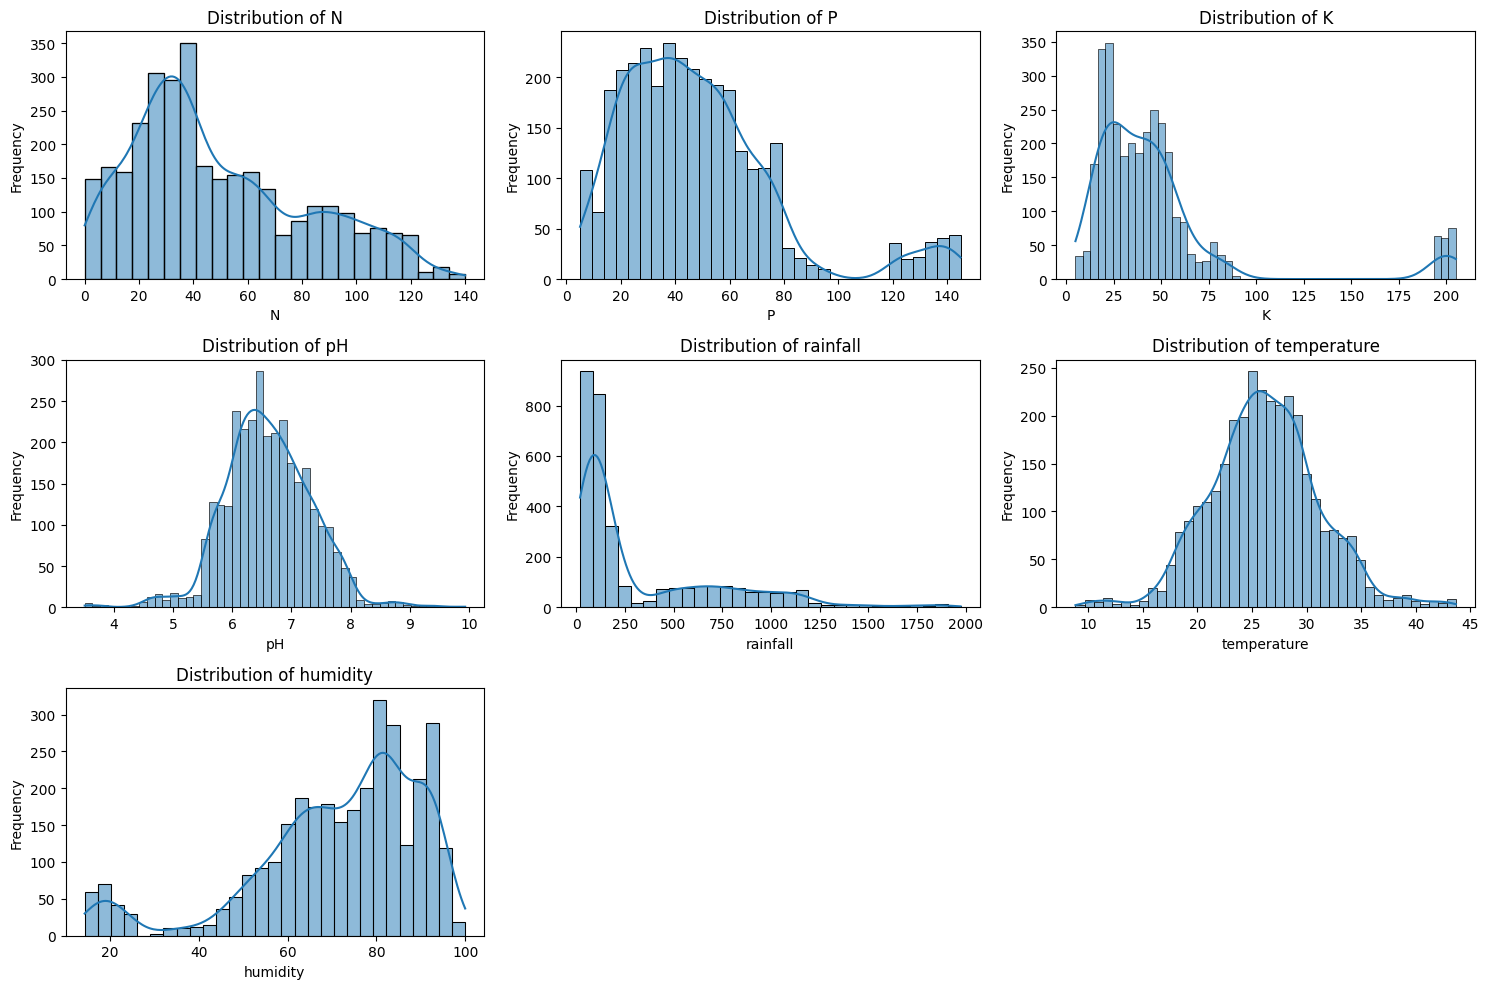

In [81]:
# Histograms of numerical features
numerical_features = ['N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'humidity']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

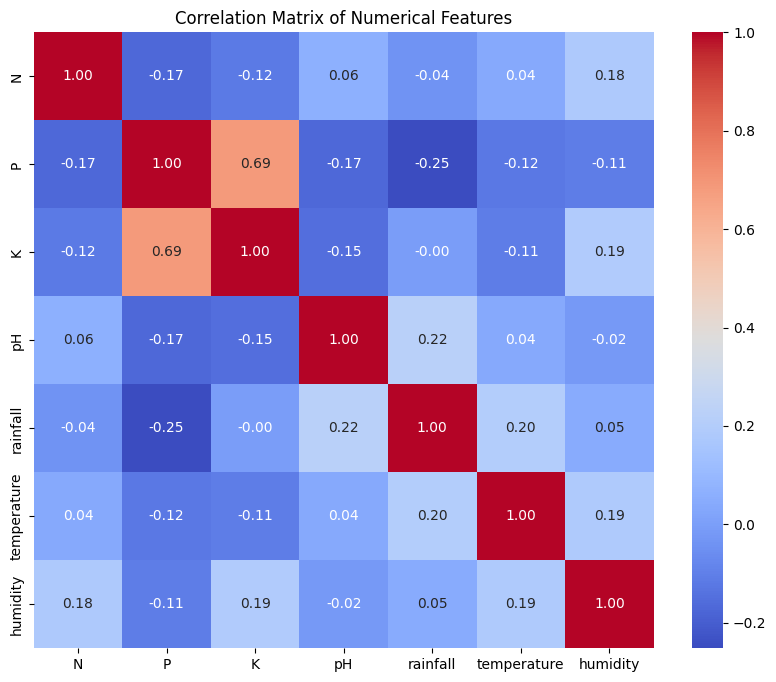

In [82]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

/tmp/ipykernel_23175/2392778186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['crop'], order=df['crop'].value_counts().index, palette='viridis')


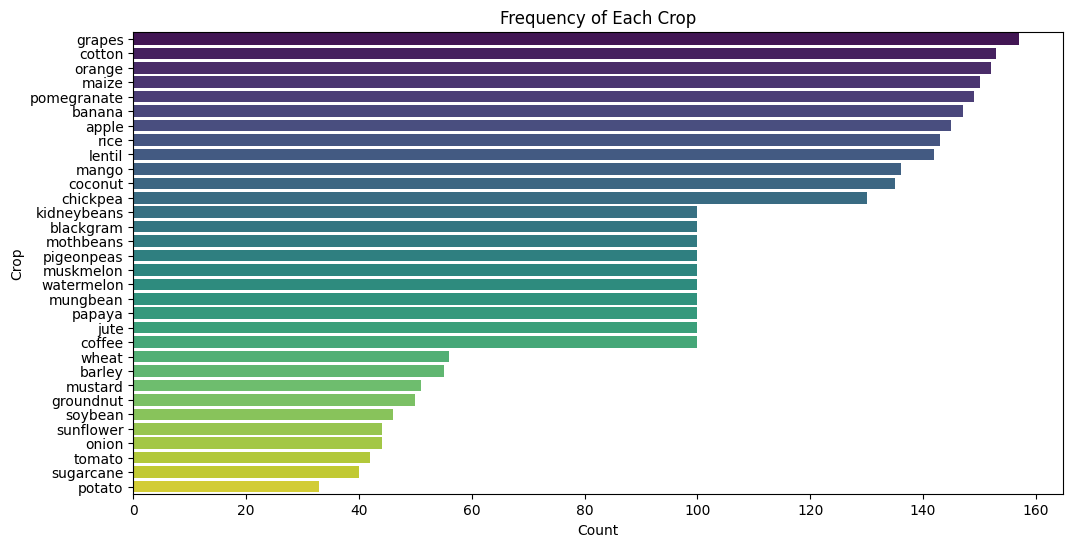

In [83]:
# Crop frequency bar plot
plt.figure(figsize=(12, 6))
sns.countplot(y=df['crop'], order=df['crop'].value_counts().index, palette='viridis')
plt.title('Frequency of Each Crop')
plt.xlabel('Count')
plt.ylabel('Crop')
plt.show()

/tmp/ipykernel_23175/4010816834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crop', y='rainfall', data=df, palette='GnBu')


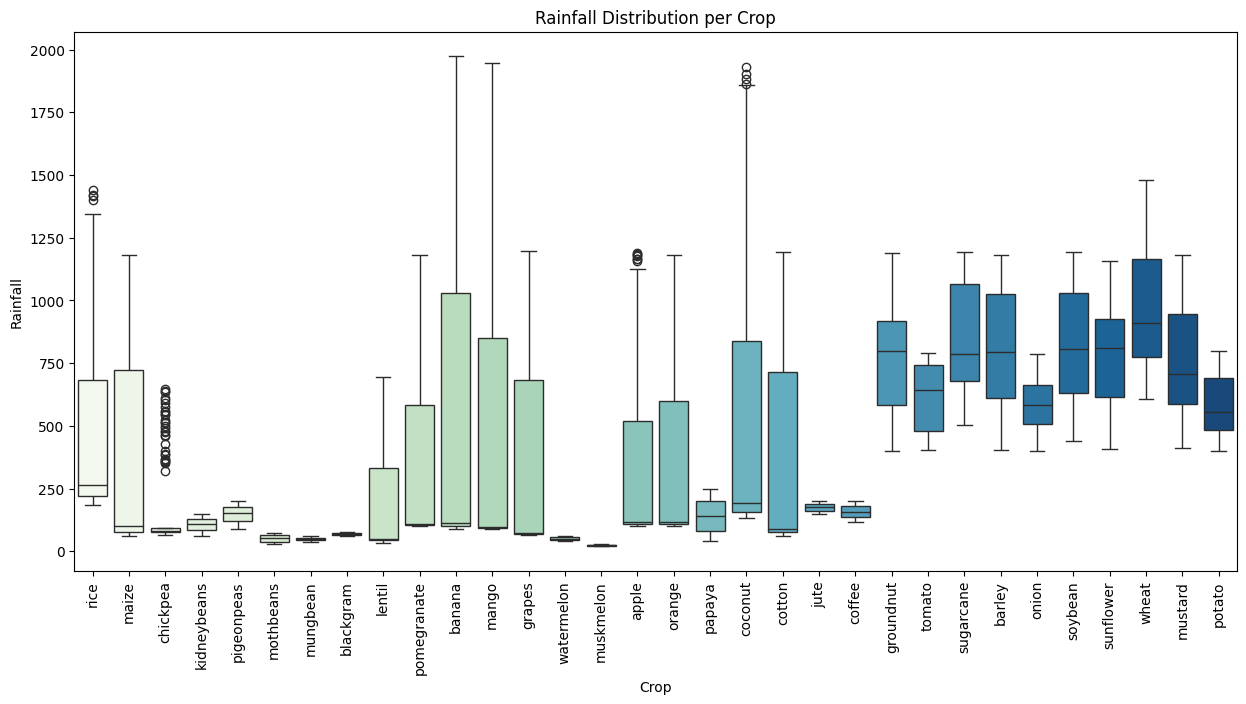

/tmp/ipykernel_23175/4010816834.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crop', y='pH', data=df, palette='PuRd')


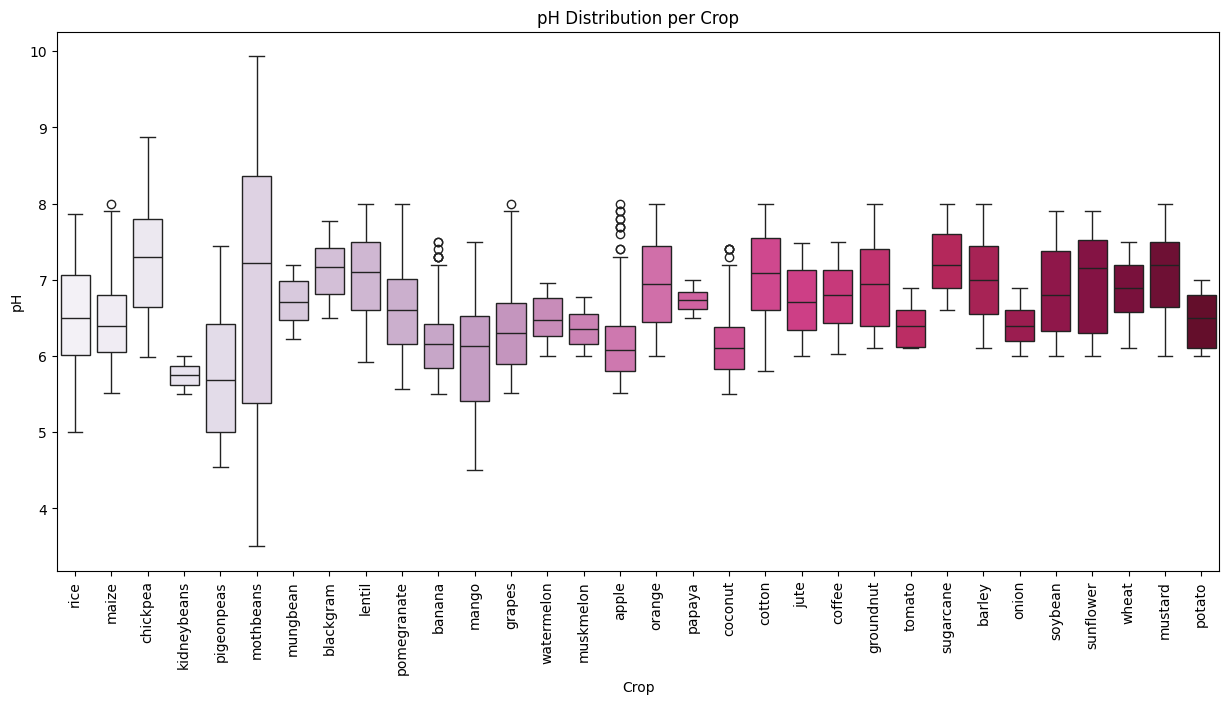

/tmp/ipykernel_23175/4010816834.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crop', y='N', data=df, palette='YlGnBu')


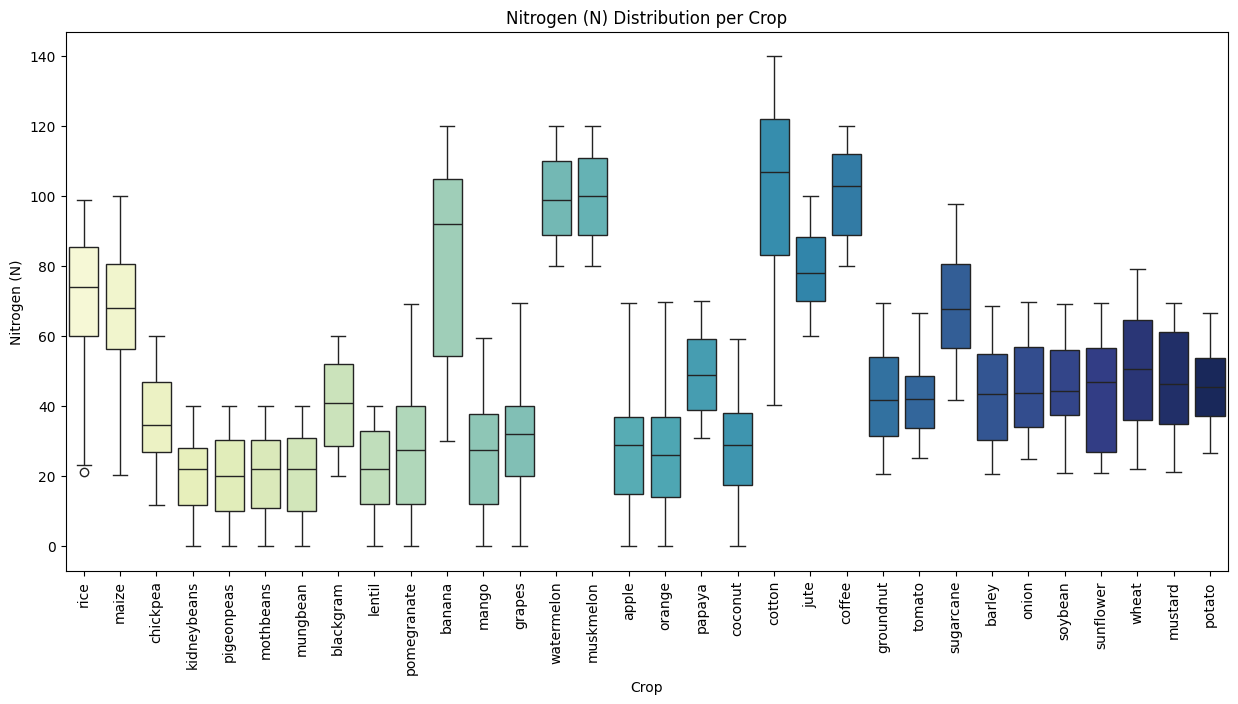

In [84]:
# Boxplots showing the relationship between specific crops and key features

# Crop vs Rainfall
plt.figure(figsize=(15, 7))
sns.boxplot(x='crop', y='rainfall', data=df, palette='GnBu')
plt.title('Rainfall Distribution per Crop')
plt.xlabel('Crop')
plt.ylabel('Rainfall')
plt.xticks(rotation=90)
plt.show()

# Crop vs pH
plt.figure(figsize=(15, 7))
sns.boxplot(x='crop', y='pH', data=df, palette='PuRd')
plt.title('pH Distribution per Crop')
plt.xlabel('Crop')
plt.ylabel('pH')
plt.xticks(rotation=90)
plt.show()

# Crop vs NPK (example for N)
plt.figure(figsize=(15, 7))
sns.boxplot(x='crop', y='N', data=df, palette='YlGnBu')
plt.title('Nitrogen (N) Distribution per Crop')
plt.xlabel('Crop')
plt.ylabel('Nitrogen (N)')
plt.xticks(rotation=90)
plt.show()

## 6. PREPROCESSING

In [85]:
# Separate features (X) and target (y)
X = df[['N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'humidity']]
y = df['crop']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Features (X) shape: (3200, 7)
Target (y) shape: (3200,)

First 5 rows of X:


,N,P,K,pH,rainfall,temperature,humidity
0,90.0,42.0,43.0,6.502985,202.935536,20.879744,82.002744
1,85.0,58.0,41.0,7.038096,226.655537,21.770462,80.319644
2,60.0,55.0,44.0,7.840207,263.964248,23.004459,82.320763
3,74.0,35.0,40.0,6.980401,242.864034,26.491096,80.158363
4,78.0,42.0,42.0,7.628473,262.717340,20.130175,81.604873



First 5 rows of y:


,crop
0,rice
1,rice
2,rice
3,rice
4,rice


## 7. ENCODING

In [86]:
# Encode the target variable (crop) using LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original crop labels:", y.unique())
print("Encoded crop labels (first 5):", y_encoded[:5])
print("Number of unique encoded labels:", len(np.unique(y_encoded)))

# Save the target label encoder for later use
joblib.dump(label_encoder, 'label_encoder.pkl')
print("LabelEncoder saved as 'label_encoder.pkl'")

Original crop labels: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee' 'groundnut' 'tomato' 'sugarcane' 'barley' 'onion'
 'soybean' 'sunflower' 'wheat' 'mustard' 'potato']
Encoded crop labels (first 5): [25 25 25 25 25]
Number of unique encoded labels: 32
LabelEncoder saved as 'label_encoder.pkl'


## 8. TRAIN-TEST SPLIT

In [87]:
# Split the dataset into training and testing sets (80-20 ratio, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2560, 7)
X_test shape: (640, 7)
y_train shape: (2560,)
y_test shape: (640,)


## 9. FEATURE SCALING

In [88]:
# Apply StandardScaler ONLY for K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and Artificial Neural Network (ANN)

scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the feature scaler
joblib.dump(scaler, 'scaler.pkl')
print("StandardScaler saved as 'scaler.pkl'")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("\nFirst 5 rows of X_train_scaled:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

StandardScaler saved as 'scaler.pkl'
X_train_scaled shape: (2560, 7)
X_test_scaled shape: (640, 7)

First 5 rows of X_train_scaled:


,N,P,K,pH,rainfall,temperature,humidity
0,0.225391,1.055784,-0.757895,1.160349,-0.682040,0.662289,-0.438080
1,-0.308059,3.295381,3.605113,-1.158844,-0.681161,2.102492,0.480272
2,0.526948,0.168090,-0.382348,-0.434465,0.743595,1.440454,0.670948
3,-0.122607,-0.466802,-0.180148,-0.158195,1.365972,1.261593,0.206231
4,-1.312200,0.275319,-0.570239,-1.477081,-0.723032,0.037206,-1.662705


## 10. MODEL TRAINING

In [89]:
results = {}

# 1. Gaussian Naive Bayes (No scaling)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
results['Gaussian Naive Bayes'] = accuracy_gnb
print(f"Gaussian Naive Bayes Accuracy: {accuracy_gnb:.4f}")

Gaussian Naive Bayes Accuracy: 0.7125


In [90]:
# 2. K-Nearest Neighbors (with scaling)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
results['K-Nearest Neighbors'] = accuracy_knn
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.4f}")

K-Nearest Neighbors Accuracy: 0.7125


In [91]:
# 3. Support Vector Machine (with scaling)
svc = SVC(probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
results['Support Vector Machine'] = accuracy_svc
print(f"Support Vector Machine Accuracy: {accuracy_svc:.4f}")

Support Vector Machine Accuracy: 0.7250


In [92]:
# 4. Random Forest (No scaling)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
results['Random Forest'] = accuracy_rf
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.7750


## 11. ANN MODEL DETAILS

In [93]:
# Convert y_train and y_test to one-hot encoded for Keras if using categorical_crossentropy
# If using sparse_categorical_crossentropy, no need to one-hot encode y.
num_classes = len(label_encoder.classes_)

# Architecture
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         1,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,648 (14.25 KB)

 Trainable params: 3,648 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Artificial Neural Network Accuracy: 0.7250


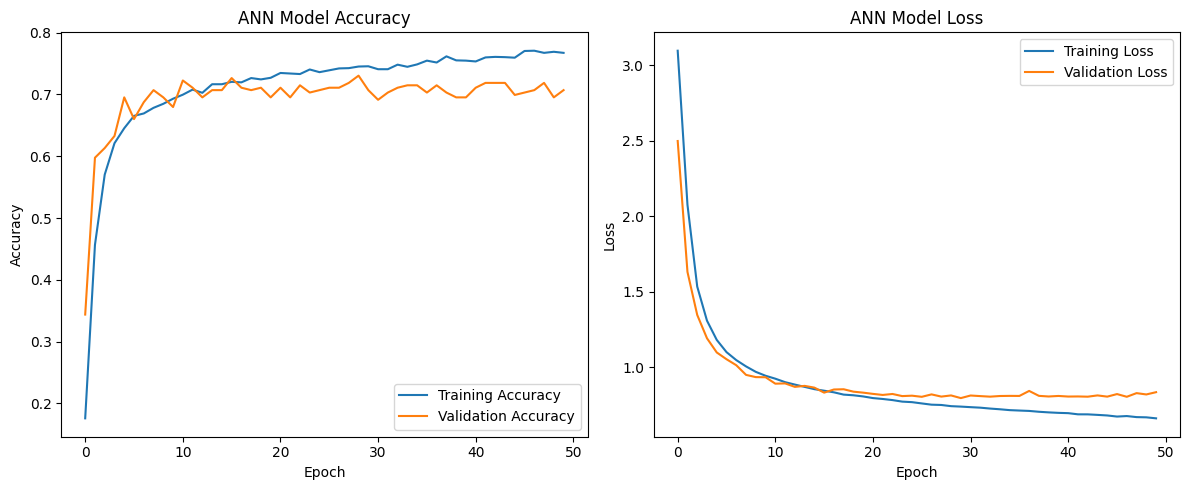

In [94]:
# Train
history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=0 # Set to 1 for progress bars
)

# Evaluate ANN
loss, accuracy_ann = ann_model.evaluate(X_test_scaled, y_test, verbose=0)
results['Artificial Neural Network'] = accuracy_ann
print(f"Artificial Neural Network Accuracy: {accuracy_ann:.4f}")

# Plot training history (optional)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 12. MODEL EVALUATION

In [95]:
print("Accuracy scores for all models on the test set:")
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")

Accuracy scores for all models on the test set:
Gaussian Naive Bayes: 0.7125
K-Nearest Neighbors: 0.7125
Support Vector Machine: 0.7250
Random Forest: 0.7750
Artificial Neural Network: 0.7250


## 13. MODEL COMPARISON

,Model,Accuracy
0,Random Forest,0.7750
1,Artificial Neural Network,0.7250
2,Support Vector Machine,0.7250
3,Gaussian Naive Bayes,0.7125
4,K-Nearest Neighbors,0.7125


/tmp/ipykernel_23175/979834007.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


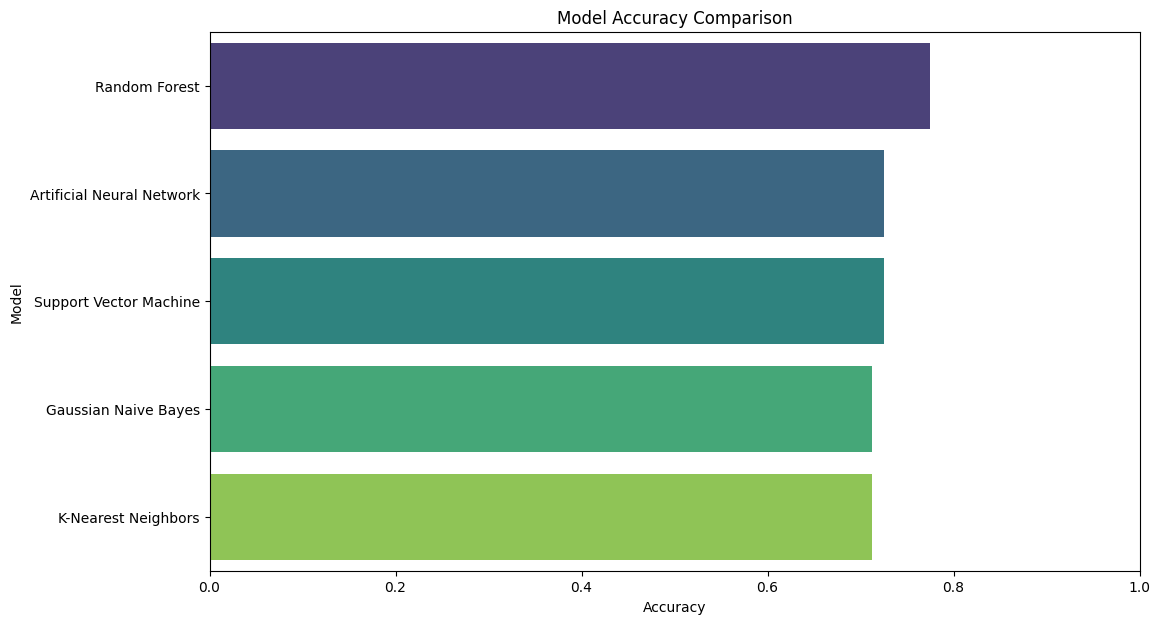

In [96]:
# Convert the results dictionary into a pandas DataFrame
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(results_df)

# Plot a bar chart comparing the accuracy of all models
plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1.0) # Accuracy ranges from 0 to 1
plt.show()

## 14. BEST MODEL SELECTION

In [97]:
# Programmatically select the model with the highest accuracy
best_model_name = results_df.loc[0, 'Model']
best_model_accuracy = results_df.loc[0, 'Accuracy']

print(f"The best performing model is: {best_model_name}")
print(f"With an accuracy of: {best_model_accuracy:.4f}")

The best performing model is: Random Forest
With an accuracy of: 0.7750


## 15. BEST MODEL VISUALIZATION

Classification Report for Random Forest:

              precision    recall  f1-score   support

       apple       0.74      0.71      0.73        28
      banana       0.60      0.90      0.72        20
      barley       0.00      0.00      0.00        10
   blackgram       1.00      1.00      1.00        16
    chickpea       0.93      0.86      0.89        29
     coconut       0.91      0.72      0.81        29
      coffee       1.00      1.00      1.00        18
      cotton       0.81      0.76      0.79        34
      grapes       0.74      0.77      0.75        30
   groundnut       0.00      0.00      0.00        10
        jute       0.93      1.00      0.96        26
 kidneybeans       1.00      1.00      1.00        19
      lentil       0.75      0.86      0.80        21
       maize       0.71      0.84      0.77        32
       mango       0.79      0.76      0.78        25
   mothbeans       0.96      1.00      0.98        27
    mungbean       1.00      1.00      

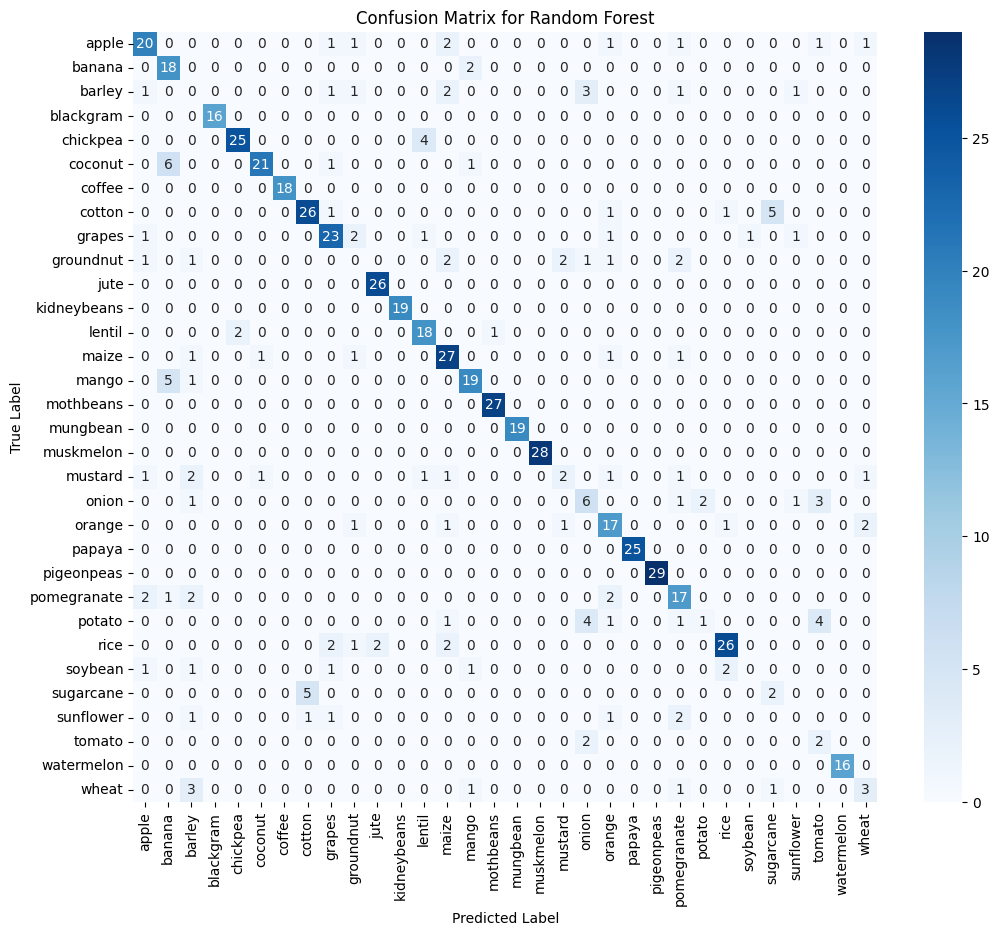

In [98]:
# Get the best model object based on its name
best_model = None
if best_model_name == 'Gaussian Naive Bayes':
    best_model = gnb
    y_pred_best = y_pred_gnb
elif best_model_name == 'K-Nearest Neighbors':
    best_model = knn
    y_pred_best = y_pred_knn
elif best_model_name == 'Support Vector Machine':
    best_model = svc
    y_pred_best = y_pred_svc
elif best_model_name == 'Random Forest':
    best_model = rf
    y_pred_best = y_pred_rf
elif best_model_name == 'Artificial Neural Network':
    best_model = ann_model
    # For ANN, predict classes directly from probabilities
    y_pred_best = np.argmax(ann_model.predict(X_test_scaled), axis=-1)

# Classification report for the best model
print(f"Classification Report for {best_model_name}:\n")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

# Plot a Confusion Matrix (heatmap) for the best model
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Feature Importances for Random Forest:


/tmp/ipykernel_23175/3971393998.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='magma')


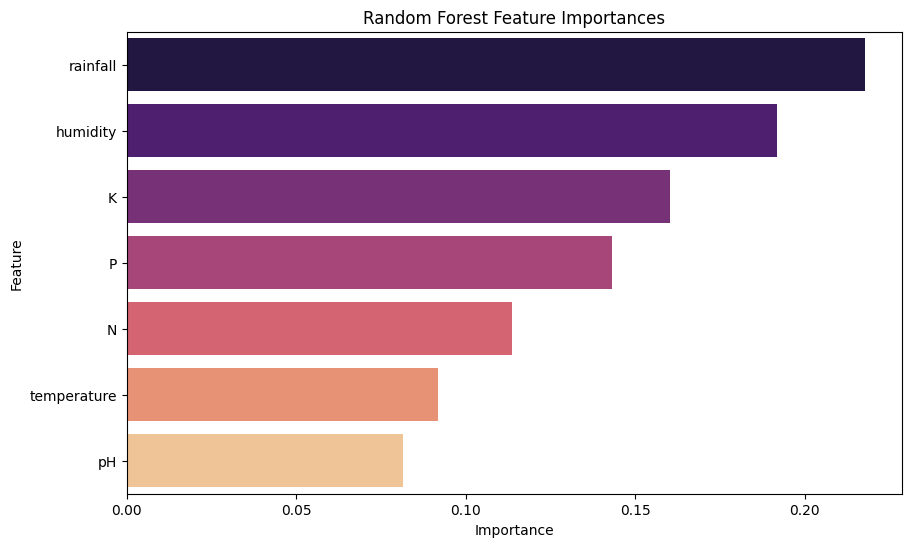

In [99]:
# If the best model (or secondary best) is Random Forest, plot its Feature Importance
if best_model_name == 'Random Forest':
    print("\nFeature Importances for Random Forest:")
    feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='magma')
    plt.title('Random Forest Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
elif 'Random Forest' in results and results['Random Forest'] == results_df.loc[1, 'Accuracy']: # Check if RF is second best
    print("\nRandom Forest is the second best model. Plotting its Feature Importances:")
    feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='magma')
    plt.title('Random Forest Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print("\nFeature Importance plot is only generated for Random Forest models.")

## 16. MODEL SAVING

In [100]:
# Save the best model
if best_model_name == 'Artificial Neural Network':
    # Keras models need to be saved differently
    ann_model.save('best_ann_model.h5')
    print("Best model (Artificial Neural Network) saved as 'best_ann_model.h5'")
else:
    joblib.dump(best_model, f'{best_model_name.lower().replace(" ", "_")}_model.pkl')
    print(f"Best model ({best_model_name}) saved as '{best_model_name.lower().replace(" ", "_")}_model.pkl'")

# We already saved the label_encoder and scaler in their respective sections.
print("LabelEncoder previously saved as 'label_encoder.pkl'")
print("StandardScaler previously saved as 'scaler.pkl'")

print("All necessary models and preprocessing objects saved successfully for deployment.")

Best model (Random Forest) saved as 'random_forest_model.pkl'
LabelEncoder previously saved as 'label_encoder.pkl'
StandardScaler previously saved as 'scaler.pkl'
All necessary models and preprocessing objects saved successfully for deployment.
